# Cognifyz Data Analyst Internship

## Level 2

### Task 1 : Restaurant Ratings

#### -->Analyze the distribution of aggregate ratings and determine the most common rating range.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use('ggplot')
from folium.plugins import MarkerCluster
from sklearn.cluster import DBSCAN

In [3]:
try:
    import folium
    from folium.plugins import MarkerCluster
    FOLIUM_AVAILABLE = True
except Exception as e:
    FOLIUM_AVAILABLE = False

In [4]:
df = pd.read_csv('C:/Users/Upendra/Downloads/Dataset .csv')

In [5]:
df.head()

,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",...,Botswana Pula(P),Yes,No,No,No,4,4.4,Green,Very Good,270
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",...,Botswana Pula(P),No,No,No,No,4,4.9,Dark Green,Excellent,365
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",...,Botswana Pula(P),Yes,No,No,No,4,4.8,Dark Green,Excellent,229


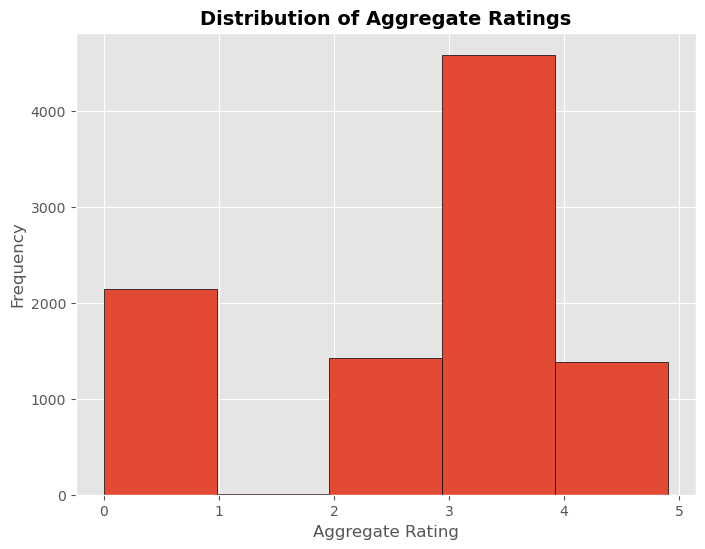

The most common rating range is between 3 and 4.


In [6]:
# Step 1: Visualize the distribution of ratings
plt.figure(figsize=(8, 6))
plt.hist(df['Aggregate rating'], bins=5, edgecolor='black')
plt.title('Distribution of Aggregate Ratings',fontsize=14, fontweight='bold')
plt.xlabel('Aggregate Rating', fontsize=12)
plt.ylabel('Frequency', fontsize = 12)
plt.grid(True)
plt.show()

# Step 2: Create bins and get the count for each bin
rating_bins = pd.cut(df['Aggregate rating'], bins=[0, 1, 2, 3, 4, 5], right=False)


# Identify the common rating range
most_common_range = rating_bins.value_counts().idxmax()

# Output the result
print(f"The most common rating range is between {most_common_range.left} and {most_common_range.right}.")

#### -->Calculate the average number of votes received by restaurants.

In [7]:
#Calculating average number of votes recieved by the restaurants.
average_votes = df['Votes'].mean()
print("The Average number of Votes recieved by Restaurants is: ",average_votes)

The Average number of Votes recieved by Restaurants is:  156.909747670401


### Task 2 : Cuisine Combination

#### -->Identify the most common combinations of cuisines in the dataset.

In [8]:
from collections import Counter

# Step 1: Handle missing values by replacing NaN with an empty list
df['Cuisines'] = df['Cuisines'].apply(lambda x: x.split(', ') if isinstance(x, str) else [])

# Step 2: Convert the list of cuisines to a sorted tuple to ensure consistency
df['Cuisine_Combination'] = df['Cuisines'].apply(lambda x: tuple(sorted(x)))

# Step 3: Count the frequency of each unique combination
combination_count = Counter(df['Cuisine_Combination'])

# Step 4: Identify the most common combinations
most_common_combinations = combination_count.most_common(30)

# Output the result
print("Most common combinations of cuisines:")
for combination, count in most_common_combinations:
    print(f"{combination}: {count} occurrences")

Most common combinations of cuisines:
('North Indian',): 936 occurrences
('Chinese', 'North Indian'): 616 occurrences
('Mughlai', 'North Indian'): 394 occurrences
('Chinese',): 354 occurrences
('Fast Food',): 354 occurrences
('Chinese', 'Mughlai', 'North Indian'): 306 occurrences
('Cafe',): 299 occurrences
('Bakery',): 218 occurrences
('Bakery', 'Desserts'): 181 occurrences
('Chinese', 'Fast Food'): 159 occurrences
('Street Food',): 149 occurrences
('Fast Food', 'Pizza'): 142 occurrences
('Chinese', 'North Indian', 'South Indian'): 135 occurrences
('Mithai', 'Street Food'): 134 occurrences
('Fast Food', 'North Indian'): 120 occurrences
('Bakery', 'Fast Food'): 117 occurrences
('South Indian',): 112 occurrences
('Desserts', 'Ice Cream'): 109 occurrences
('Chinese', 'Continental', 'North Indian'): 107 occurrences
('Mughlai',): 103 occurrences
('Chinese', 'Fast Food', 'North Indian'): 102 occurrences
('Burger', 'Fast Food'): 99 occurrences
('Ice Cream',): 74 occurrences
('Mithai',): 71 oc

#### -->Determine if certain cuisine combinations tend to have higher ratings.

In [9]:
import numpy as np


# Step 3: Group by cuisine combination and calculate the average rating for each
average_ratings = df.groupby('Cuisine_Combination')['Aggregate rating'].mean().reset_index()

# Step 4: Sort the combinations by average rating
average_ratings = average_ratings.sort_values(by='Aggregate rating', ascending=False)

# Output the result
print("Cuisine combinations with their average ratings:")
print(average_ratings)

Cuisine combinations with their average ratings:
                                    Cuisine_Combination  Aggregate rating
1343                                   (World Cuisine,)               4.9
32                            (American, BBQ, Sandwich)               4.9
159                           (American, Sandwich, Tea)               4.9
1167                                (Indonesian, Sunda)               4.9
1132                                (Hawaiian, Seafood)               4.9
...                                                 ...               ...
930     (Continental, Fast Food, Italian, North Indian)               0.0
934   (Continental, Fast Food, North Indian, South I...               0.0
371   (Bakery, Chinese, Mithai, North Indian, South ...               0.0
504           (Biryani, Fast Food, Healthy Food, Pizza)               0.0
1238                  (Lucknowi, Mughlai, North Indian)               0.0

[1344 rows x 2 columns]


## Task3: Geographic Analysis

#### -->Plot the locations of restaurants on a map using longitude and latitude coordinates.

In [10]:
# Try to auto-detect columns (adjust if needed)
lat_col = [c for c in df.columns if "lat" in c.lower()][0]
lon_col = [c for c in df.columns if ("lon" in c.lower() or "lng" in c.lower() or "long" == c.lower())][0]

# Clean: keep valid numeric coordinates
df[lat_col] = pd.to_numeric(df[lat_col], errors="coerce")
df[lon_col] = pd.to_numeric(df[lon_col], errors="coerce")
df = df.dropna(subset=[lat_col, lon_col])
df = df[(df[lat_col].between(-90, 90)) & (df[lon_col].between(-180, 180))].copy()

df.head()

,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes,Cuisine_Combination
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"[French, Japanese, Desserts]",...,Yes,No,No,No,3,4.8,Dark Green,Excellent,314,"(Desserts, French, Japanese)"
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,[Japanese],...,Yes,No,No,No,3,4.5,Dark Green,Excellent,591,"(Japanese,)"
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"[Seafood, Asian, Filipino, Indian]",...,Yes,No,No,No,4,4.4,Green,Very Good,270,"(Asian, Filipino, Indian, Seafood)"
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"[Japanese, Sushi]",...,No,No,No,No,4,4.9,Dark Green,Excellent,365,"(Japanese, Sushi)"
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"[Japanese, Korean]",...,Yes,No,No,No,4,4.8,Dark Green,Excellent,229,"(Japanese, Korean)"


In [11]:
lat_col = "Latitude"
lon_col = "Longitude"

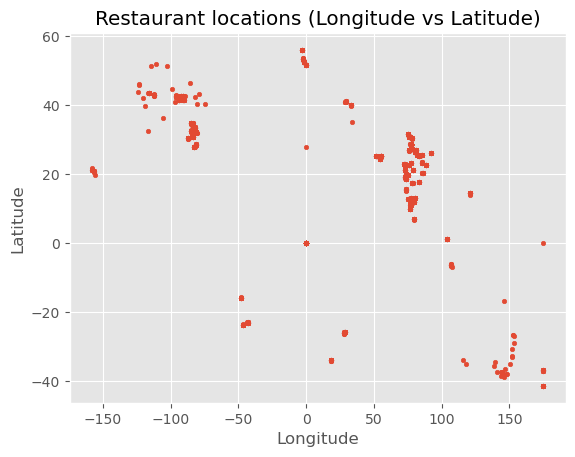

In [12]:
plt.figure()
plt.scatter(df[lon_col], df[lat_col], s=10)  # no specific colors
plt.title("Restaurant locations (Longitude vs Latitude)")
plt.xlabel(lon_col); plt.ylabel(lat_col)
plt.show()


In [17]:
lat_center = df[lat_col].mean()
lon_center = df[lon_col].mean()

m = folium.Map(location=[lat_center, lon_center], zoom_start=12)
mc = MarkerCluster().add_to(m)

name_col = next((c for c in df.columns if any(k in c.lower() for k in ["name","restaurant","title","place"])), None)

for _, r in df.iterrows():
    popup = ""
    if name_col:
        popup += f"<b>{r[name_col]}</b><br>"
    popup += f"Lat: {r[lat_col]:.5f}, Lon: {r[lon_col]:.5f}"
    folium.Marker([r[lat_col], r[lon_col]], popup=popup).add_to(mc)

m.save("restaurants_map.html")

In [18]:
coords_rad = np.radians(df[[lat_col, lon_col]].to_numpy())

# Neighborhood size = ~1.0 km. You can try 0.5, 1, 2, 3 to see changes.
eps_km = 1.0
eps_rad = eps_km / 6371.0088  # Earth radius in km

db = DBSCAN(eps=eps_rad, min_samples=5, algorithm="ball_tree", metric="haversine").fit(coords_rad)
df["cluster"] = db.labels_
df["cluster"].value_counts().sort_index()

cluster
-1     984
 0      15
 1      13
 2       7
 3      11
      ... 
 92      5
 93      6
 94      9
 95      6
 96      5
Name: count, Length: 98, dtype: int64

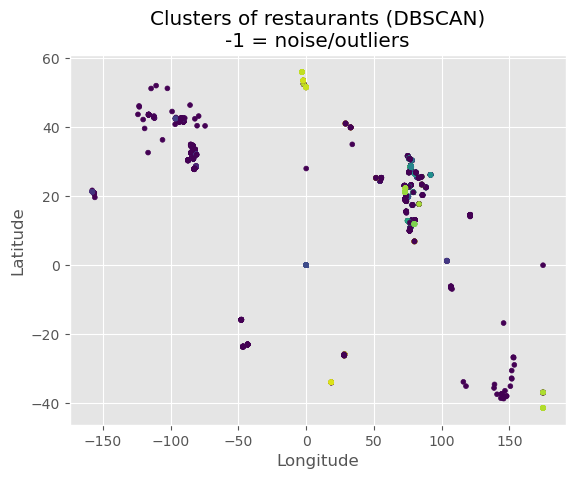

In [19]:
plt.figure()
plt.scatter(df[lon_col], df[lat_col], s=12, c=df["cluster"])  # default colormap, -1 = noise
plt.title("Clusters of restaurants (DBSCAN)\n-1 = noise/outliers")
plt.xlabel(lon_col); plt.ylabel(lat_col)
plt.show()

## Task4: Restaurant Chains

#### -->Identify if there are any restaurant chains present in the dataset.

In [16]:
chain_counts=df['Restaurant Name'].value_counts()
restaurant_chains=chain_counts[chain_counts>1]
print('Restaurant Name')
print(restaurant_chains)

Restaurant Name
Restaurant Name
Cafe Coffee Day       83
Domino's Pizza        79
Subway                63
Green Chick Chop      51
McDonald's            48
                      ..
Town Hall              2
Halki Aanch            2
Snack Junction         2
Delhi Biryani Hut      2
Beliram Degchiwala     2
Name: count, Length: 734, dtype: int64


Top 10 restaurant chains:
                                Aggregate rating  Votes
Restaurant Name                                        
Restaurant Mosaic @ The Orient               4.9     85
Ministry of Crab                             4.9    203
Miann                                        4.9    281
Shorts Burger and Shine                      4.9    820
Milse                                        4.9    754
Yellow Dog Eats                              4.9   1252
Duck & Waffle                                4.9    706
Gaga Manjero                                 4.9     95
Mirchi And Mime                              4.9   3244
McGuire's Irish Pub & Brewery                4.9   2238


C:\Users\Upendra\AppData\Local\Temp\ipykernel_36984\3685275002.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_chains.index,y=top_chains['Aggregate rating'],palette='Blues')
C:\Users\Upendra\AppData\Local\Temp\ipykernel_36984\3685275002.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_chains.index,y=top_chains['Votes'],palette='Reds')


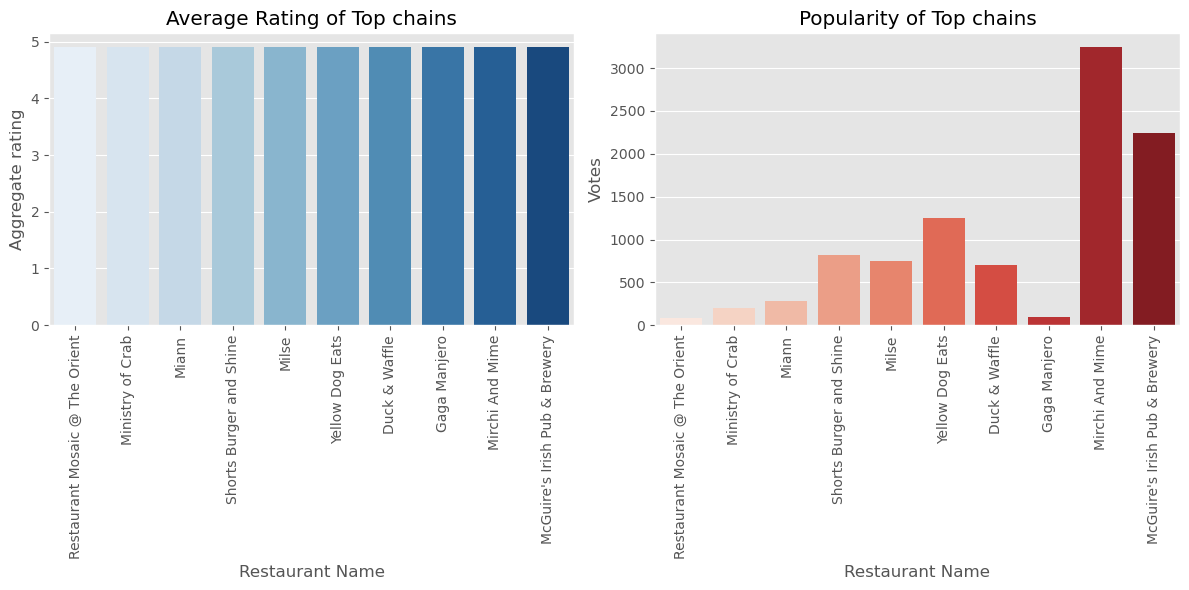

In [20]:
chain_stats= df.groupby('Restaurant Name').agg({'Aggregate rating':'mean','Votes':'sum'})
chain_stats=chain_stats.sort_values(by='Aggregate rating',ascending=False)
top_chains=chain_stats.head(10)
print('Top 10 restaurant chains:')
print(top_chains)

plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
sns.barplot(x=top_chains.index,y=top_chains['Aggregate rating'],palette='Blues')
plt.xticks(rotation=90)
plt.title('Average Rating of Top chains')

plt.subplot(1,2,2)
sns.barplot(x=top_chains.index,y=top_chains['Votes'],palette='Reds')
plt.xticks(rotation=90)
plt.title('Popularity of Top chains')
plt.tight_layout()
plt.show()